In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("social_collaboration_network.csv")
df.head()

,Person_A,Person_B,Collaboration_Score
0,Alex,Bella,4
1,Alex,Carlos,2
2,Bella,Dina,3
3,Carlos,Eli,4
4,Dina,Eli,3


In [2]:
# Create graph from edges with weights
G = nx.Graph()
for index, row in df.iterrows():
    G.add_edge(row['Person_A'], row['Person_B'], weight=row['Collaboration_Score'])

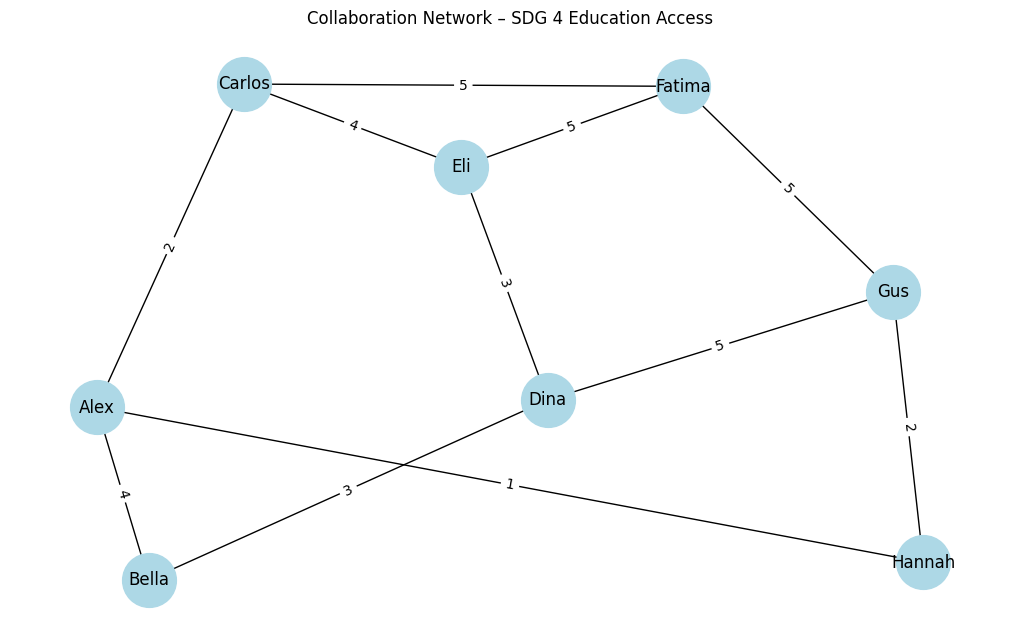

In [3]:
# Draw the graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.title("Collaboration Network – SDG 4 Education Access")
plt.show()

In [4]:
# Degree (number of direct connections)
for node in G.nodes():
    print(f"{node} has degree {G.degree(node)}")

Alex has degree 3
Bella has degree 2
Carlos has degree 3
Dina has degree 3
Eli has degree 3
Fatima has degree 3
Gus has degree 3
Hannah has degree 2


In [5]:
# Centrality (who connects groups)
centrality = nx.betweenness_centrality(G, weight='weight')
print("\nBetweenness Centrality:")
for node, score in centrality.items():
    print(f"{node}: {round(score, 3)}")


Betweenness Centrality:
Alex: 0.31
Bella: 0.048
Carlos: 0.167
Dina: 0.119
Eli: 0.119
Fatima: 0.0
Gus: 0.095
Hannah: 0.143


In [6]:
#Who appears to be a central connector?
central_connector = nx.betweenness_centrality(G)
top_connector = max(central_connector, key=central_connector.get) #Tells max() to compare the scores and not the string values of names
print(f"\nThe central connector is {top_connector} with a score of: {round(central_connector[top_connector],3)}")


The central connector is Alex with a score of: 0.175


In [7]:
#Who has the lowest connections?
lowest_connector = nx.betweenness_centrality(G)
low_connector = min(lowest_connector, key=lowest_connector.get)
print(f"\nThe lowest connector is {low_connector} with a score of: {round(lowest_connector[low_connector],3)}")


The lowest connector is Bella with a score of: 0.048


In [9]:
G.add_edge("Isla", "Alex", weight=3)
G.remove_edge("Carlos", "Fatima")

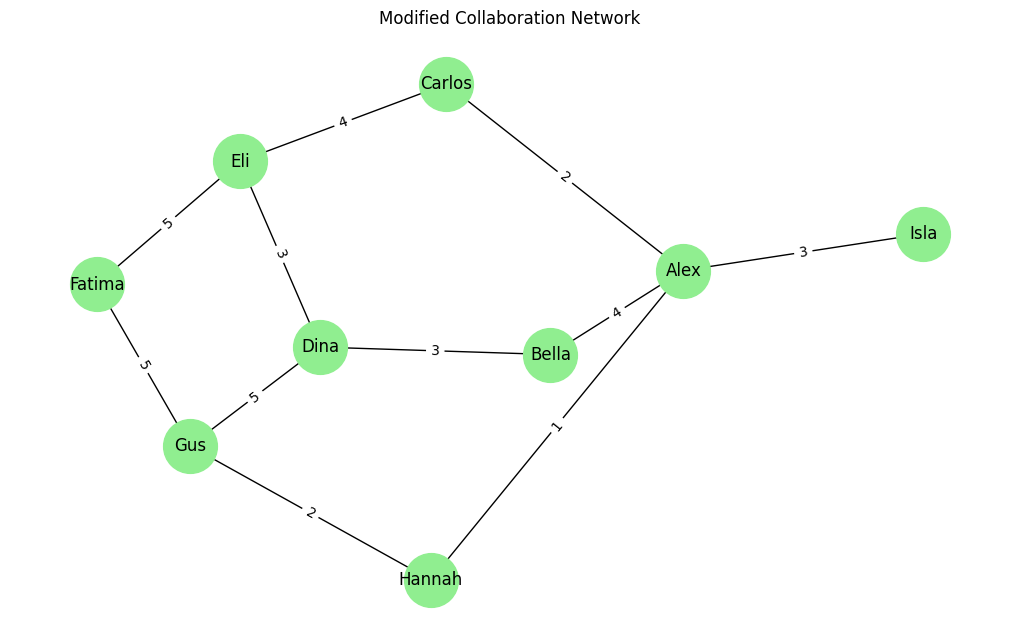

In [11]:
plt.figure(figsize=(10,6))
pos = nx.spring_layout(G) 
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.title("Modified Collaboration Network")
plt.show()

In [12]:
#Who appears to be the new central connector?
central_connector = nx.betweenness_centrality(G)
top_connector = max(central_connector, key=central_connector.get) #Tells max() to compare the scores and not the string values of names
print(f"\nThe central connector is {top_connector} with a score of: {round(central_connector[top_connector],3)}")


The central connector is Alex with a score of: 0.381


In [13]:
#Who has the lowest connections now?
lowest_connector = nx.betweenness_centrality(G)
low_connector = min(lowest_connector, key=lowest_connector.get)
print(f"\nThe lowest connector is {low_connector} with a score of: {round(lowest_connector[low_connector],3)}")


The lowest connector is Isla with a score of: 0.0
